# Named constraints and explainable optimization

Every optimizer in jaxfolio already takes `long_only` and `weight_bounds`. Those are
*anonymous*: they shape the answer but leave no trace in it. If an asset comes back at
0%, nothing in the result says whether it was excluded on its own merits or crowded out
by a limit somewhere else.

This notebook walks through the two features that fix that:

1. **Named constraints** — `GroupCap`, `GroupFloor`, `Box`, `Budget`. A cap that carries
   an identity, enforced by an *exact* Euclidean projection rather than a penalty that
   lands "near" feasible.
2. **`jf.explain`** — the Lagrange multipliers recovered from that projection, reported
   as the shadow price of each named row and the reason each asset holds the weight it
   does.

Reference: [constraints guide](../../docs/guide/constraints.md) ·
[explainable optimization guide](../../docs/guide/attribution.md) · the script version of
part of this notebook is [`examples/07_constraints.py`](../07_constraints.py).


In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

import jaxfolio as jf
from jaxfolio import viz
from jaxfolio.constraints import InfeasibleConstraints, check_feasible
from jaxfolio.viz import theme

# Multipliers are small numbers next to weights of order 0.1 — significant figures keep
# both readable in the same frame.
pd.set_option("display.float_format", lambda v: f"{v:.5g}")

returns = jf.generate_returns(n_assets=9, n_days=500, seed=42)
assets = list(returns.columns)
returns.tail(3)

,ASSET_00,ASSET_01,ASSET_02,ASSET_03,ASSET_04,ASSET_05,ASSET_06,ASSET_07,ASSET_08
2022-11-29,-0.0070048,-0.027646,-0.015346,0.00077493,0.0062107,-0.013075,0.031474,-0.035074,-0.0066188
2022-11-30,0.0044794,-0.012589,0.037502,0.019373,0.0033083,0.045108,-0.047928,0.027296,0.0025897
2022-12-01,-0.02185,0.0098548,-0.021626,0.013269,0.0051803,0.0042468,-0.042153,0.0039215,0.0056244


## A universe with three sectors

Group rows must **partition** the universe — each asset in at most one group — so the
nine synthetic assets split into three disjoint sectors of three.

On synthetic data the labels are arbitrary, so the three names the *unconstrained*
optimizer likes most go into `tech`. Otherwise the cap would sit above the natural
exposure and never bind, and the whole demonstration would be vacuous.

In [2]:
free = jf.minimum_variance(returns)


def exposure(result: jf.PortfolioResult, members: list[str]) -> float:
    """Summed weight of `members` in a solved portfolio."""
    idx = [result.assets.index(m) for m in members]
    return float(np.asarray(result.weights)[idx].sum())


ranked = [assets[i] for i in np.argsort(-np.asarray(free.weights))]
tech, energy, financials = ranked[:3], ranked[3:6], ranked[6:]

SECTORS = (("tech", tech), ("energy", energy), ("financials", financials))
sector = {a: label for label, members in SECTORS for a in members}

for label, members in SECTORS:
    print(f"{label:<11} {', '.join(members):<26} unconstrained {exposure(free, members):>7.2%}")

tech        ASSET_04, ASSET_08, ASSET_06 unconstrained  71.61%
energy      ASSET_01, ASSET_05, ASSET_02 unconstrained  24.43%
financials  ASSET_03, ASSET_00, ASSET_07 unconstrained   3.97%


## 1. A cap is a guarantee, not a preference

`GroupCap("tech", tech, max=0.30)` holds at **exactly** 30.00% — the solver reaches the
true constrained optimum rather than an approximately feasible point nearby. The freed
weight is redistributed by the objective, not by a rule of thumb.

In [3]:
TECH_CAP = 0.30

capped = jf.minimum_variance(returns, constraints=[jf.GroupCap("tech", tech, max=TECH_CAP)])

comparison = pd.DataFrame(
    {
        "sector": [sector[a] for a in assets],
        "unconstrained": free.weights,
        "tech_capped": capped.weights,
    },
    index=assets,
)
comparison["delta"] = comparison["tech_capped"] - comparison["unconstrained"]
comparison

,sector,unconstrained,tech_capped,delta
ASSET_00,financials,0.016212,0.12786,0.11165
ASSET_01,energy,0.10149,0.23505,0.13356
ASSET_02,energy,0.052267,0.12657,0.074306
ASSET_03,financials,0.023441,0.078059,0.054619
ASSET_04,tech,0.40992,0.15366,-0.25626
ASSET_05,energy,0.090511,0.091312,0.00080047
ASSET_06,tech,0.10439,0.14634,0.041944
ASSET_07,financials,0,0.041147,0.041147
ASSET_08,tech,0.20176,0,-0.20176


In [4]:
print(f"tech exposure : {exposure(free, tech):.6f} -> {exposure(capped, tech):.6f}")
print(f"budget        : {free.weights.sum():.6f} -> {capped.weights.sum():.6f}")
print(f"annual vol    : {free.volatility:.6f} -> {capped.volatility:.6f}")

tech exposure : 0.716076 -> 0.300000
budget        : 1.000000 -> 1.000000
annual vol    : 0.064195 -> 0.093596


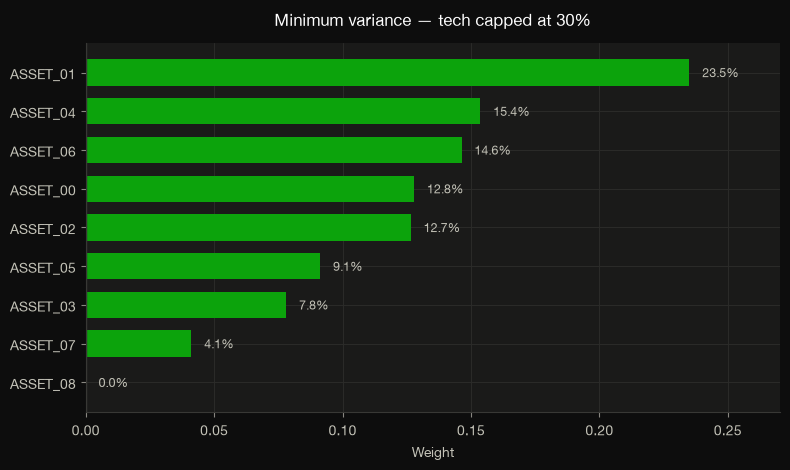

In [5]:
fig = viz.plot_weights(capped, title=f"Minimum variance — tech capped at {TECH_CAP:.0%}")
plt.show()

## 2. What the cap costs

The optimizer minimizes per-period variance `w'Σw`, so the price of the cap is the
objective gap against the unconstrained optimum. Constraints can only ever weakly hurt
the in-sample objective — that invariant is what makes the shadow prices below readable.

In [6]:
_mu, cov, _names, _ = jf.toolkit.moments(returns)
cov = np.asarray(cov)


def variance(result: jf.PortfolioResult) -> float:
    """Per-period portfolio variance under the same moments the solver used."""
    w = np.asarray(result.weights)
    return float(w @ cov @ w)


gap = variance(capped) - variance(free)
print(f"variance, unconstrained : {variance(free):.8f}")
print(f"variance, tech <= 30%   : {variance(capped):.8f}")
print(f"cost of the cap         : {gap:+.8f}  ({gap / variance(free):+.2%})")

variance, unconstrained : 0.00001635
variance, tech <= 30%   : 0.00003476
cost of the cap         : +0.00001841  (+112.58%)


## 3. `Box` composes predictably

An **unscoped** `Box` *replaces* the bounds implied by `long_only` / `weight_bounds`; an
`assets`-scoped `Box` *intersects* with whatever is already in force. So per-name
overrides stack, and a tighter limit on one illiquid name does not disturb the rest.

Mind the arithmetic in a small universe: nine assets under a 10% box reach at most 90% and
could not fund the budget at all, so the bounds below are 20% and 5%.

In [7]:
illiquid = tech[0]

boxed = jf.minimum_variance(
    returns,
    constraints=[
        jf.Box(lower=0.0, upper=0.20),  # everything at 20%
        jf.Box(upper=0.05, assets=[illiquid], name="illiquid"),  # tighter on one name
    ],
)

print(f"largest position   : {boxed.weights.max():.4f}   (unscoped box upper 0.20)")
print(f"{illiquid:<18} : {boxed.weights[assets.index(illiquid)]:.4f}   (scoped box upper 0.05)")
pd.Series(boxed.weights, index=assets, name="weight").to_frame().T

largest position   : 0.2000   (unscoped box upper 0.20)
ASSET_04           : 0.0500   (scoped box upper 0.05)


,ASSET_00,ASSET_01,ASSET_02,ASSET_03,ASSET_04,ASSET_05,ASSET_06,ASSET_07,ASSET_08
weight,0.11816,0.13375,0.07109,0.08133,0.05,0.078243,0.2,0.067423,0.2


## 4. `jf.explain` — why each asset is where it is

Now three named rows: a cap that binds, a cap that does not, and a floor. `jf.explain` is pure post-processing over a
payload captured at solve time — no second solve, and no second solver. At a solution the
weights are a fixed point of the projection, so projecting `w* - s∇f` and keeping the
projection's *own* multipliers hands back the portfolio problem's multipliers divided
by `s`.

In [8]:
detailed = jf.minimum_variance(
    returns,
    constraints=[
        jf.GroupCap("tech", tech, max=TECH_CAP),
        jf.GroupCap("energy", energy, max=0.50),
        jf.GroupFloor("financials", financials, min=0.15),
    ],
)

report = jf.explain(detailed)
print(report.explain_text(top_n=6))

Constraint attribution — Minimum Variance (9 assets)
  quality: exact  ·  stationarity 2.72e-04
  cost of capital (budget): +0.00010 per unit

Asset ASSET_08: 0.00%   [at lower]
  binding: tech (group_cap)   shadow price -0.00009
  own merit -0.00009  ·  charged by tech +0.00009  ·  net +0.00000

Asset ASSET_01: 23.50%
  cause: own merits (interior)

Asset ASSET_04: 15.36%
  cause: own merits (interior)

Asset ASSET_06: 14.64%
  cause: own merits (interior)

Asset ASSET_00: 12.79%
  cause: own merits (interior)

Asset ASSET_02: 12.66%
  cause: own merits (interior)


Read the `own merit` / `charged by` line for an asset sitting at 0%: a **negative** own
merit means it wants in, and the row that charges it enough to push the net over the line
is the real cause. That asset was not excluded because it is unattractive — its sector
was full.

Attribution ranks the **terms** of the reduced-cost decomposition
`rc_i = (g_i + λ) + θ_k(i)`, not the multipliers. Ranking multipliers looks right and is
wrong: at a zero weight the box multiplier equals the *entire* reduced cost, so
`box_lower` would win every time and "binding: tech" could never fire.

### Three figures for reading a report

That is the report as text. The three helpers below read the *same* report as pictures —
they take nothing but `to_frame()`, `constraints_frame()` and `for_asset()`, so every
number in them is also available in a frame.

Colors come from `jaxfolio.viz.theme`: one accent hue for the marks that carry the story,
a de-emphasis gray for context, and the warm pole of the diverging pair reserved for the
opposite sign. Nothing here is decorative — a hue change always means a change of claim.

In [9]:
ACCENT = theme.CATEGORICAL[0]  # the mark that carries the story
WARM = "#e66767"  # the opposite pole of the diverging pair
MUTED = "#6f6e68"  # de-emphasis: context, not subject


def _percent(value, _pos):
    return f"{value:.0%}"


def _axes(ax, width, height):
    if ax is not None:
        return ax.figure, ax
    return plt.subplots(figsize=(width, height))


def plot_asset_attribution(report, *, ax=None, title=None):
    """Weights, colored by *what put each asset there* — own merits, or a named row.

    The emphasis form: only the assets a constraint is responsible for take the accent
    hue, and only those carry a direct label. An asset held at 0% has no bar to see, so it
    gets a tick at the baseline instead.
    """
    frame = report.to_frame().sort_values("weight")
    causes = [None if row == "own" else row for row in frame["binding"]]
    weights = frame["weight"].to_numpy()

    fig, ax = _axes(ax, 8.4, 0.42 * len(weights) + 1.7)
    ax.barh(
        list(frame.index),
        weights,
        color=[ACCENT if cause else MUTED for cause in causes],
        height=0.62,
    )
    for y, (weight, cause) in enumerate(zip(weights, causes, strict=True)):
        if cause is None:
            continue
        # A holding of 0% has no bar to carry the accent hue, so the row itself is banded
        # and the baseline gets a tick — emphasis without inventing a length.
        ax.axhspan(y - 0.46, y + 0.46, color=theme.HIGHLIGHT, zorder=0)
        ax.plot([0], [y], marker="|", markersize=15, markeredgewidth=3, color=ACCENT)
        ax.annotate(
            f"{weight:.2%} — {cause}",
            (weight, y),
            xytext=(10, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
            color=theme.INK_SECONDARY,
        )

    ax.set_xlim(0, max(weights.max() * 1.3, 0.05))
    ax.xaxis.set_major_formatter(_percent)
    ax.set_xlabel("weight")
    ax.grid(axis="y", visible=False)
    ax.set_title(title or f"What put each asset where it is — {report.method}")
    ax.legend(  # below the axes: an emphasized row can occupy any corner of the plot
        handles=[
            Patch(facecolor=ACCENT, label="set by a named constraint"),
            Patch(facecolor=MUTED, label="own merits"),
        ],
        loc="upper left",
        bbox_to_anchor=(0, -0.12),
        ncol=2,
        frameon=False,
        fontsize=9,
    )
    fig.tight_layout()
    return fig


def plot_constraint_activity(report, *, ax=None):
    """Each named row's exposure against the bound it is up against.

    A bar per row — accent when binding, gray when slack — a tick at each reachable bound,
    and the shadow price direct-labeled only where there is one to quote.
    """
    frame = report.constraints_frame()
    fig, ax = _axes(ax, 8.4, 0.62 * len(frame) + 1.9)

    reach = [frame["activity"].max()]
    for y, (_name, row) in enumerate(frame.iterrows()):
        binding = row["status"] == "binding"
        ax.barh(y, row["activity"], color=ACCENT if binding else MUTED, height=0.46)

        # Only bounds that are reachable at all: a cap at or above the budget, or a floor
        # at zero, constrains nothing and would read as a limit that is doing work.
        note_x = row["activity"]
        for bound, kind in ((row["lower"], "floor"), (row["upper"], "cap")):
            if not 0 < bound < 1.0:
                continue
            reach.append(bound)
            note_x = max(note_x, bound)
            ax.plot([bound, bound], [y - 0.33, y + 0.33], color=theme.INK_MUTED, linewidth=1.4)
            if binding and abs(bound - row["activity"]) < 1e-6:
                ax.annotate(  # above the bar: below it, the label would sit on the mark
                    f"{kind} {bound:.0%}",
                    (bound, y - 0.42),
                    ha="center",
                    va="bottom",
                    fontsize=8.5,
                    color=theme.INK_MUTED,
                )

        note = (
            f"shadow price {row['shadow_price']:+.2e}" if binding else f"slack {row['slack']:.2%}"
        )
        ax.annotate(
            note,
            (note_x, y),
            xytext=(12, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
            color=theme.INK_SECONDARY if binding else theme.INK_MUTED,
        )

    ax.set_yticks(range(len(frame)), list(frame.index))
    ax.set_ylim(len(frame) - 0.5, -0.85)  # headroom for the bound label on the first row
    ax.set_xlim(0, max(reach) * 1.45)
    ax.xaxis.set_major_formatter(_percent)
    ax.set_xlabel("group exposure")
    ax.grid(axis="y", visible=False)
    ax.set_title("Which constraint is actually moving the optimum")
    fig.tight_layout()
    return fig


def plot_reduced_cost(report, asset, *, ax=None):
    """The pricing identity for one asset: intrinsic + imposed = net reduced cost.

    Signed magnitude, so the two poles of the diverging pair carry the meaning: cool means
    the asset wants in, warm means something is charging it to stay out.
    """
    detail = report.for_asset(asset)
    terms = [("own merit", detail.intrinsic_cost)]
    terms += [(f"charged by {name}", value) for name, value in detail.imposed]
    terms += [("net reduced cost", detail.reduced_cost)]
    values = [value for _label, value in terms]

    ys = [float(len(terms) - 1 - i) for i in range(len(terms))]
    ys[-1] -= 0.35  # a gap: the last bar is the sum of the ones above it, not a sibling

    fig, ax = _axes(ax, 8.4, 0.72 * len(terms) + 1.8)
    ax.barh(ys, values, color=[WARM if v > 0 else ACCENT for v in values], height=0.5)
    ax.axvline(0, color=theme.BASELINE, linewidth=1.2)

    for y, value in zip(ys, values, strict=True):
        ax.annotate(
            f"{value:+.2e}",
            (value, y),
            xytext=(11 if value >= 0 else -11, 0),
            textcoords="offset points",
            ha="left" if value >= 0 else "right",
            va="center",
            fontsize=9,
            color=theme.INK_SECONDARY,
        )

    reach = max(abs(v) for v in values) or 1.0
    status = detail.status.replace("_", " ")
    ax.annotate(
        "the net is what decides:\nabove zero, the asset stays at its bound",
        (-reach * 1.4, ys[-1]),
        va="center",
        fontsize=9,
        color=theme.INK_MUTED,
    )
    ax.set_xlim(-reach * 1.45, reach * 1.45)
    ax.set_yticks(ys, [label for label, _value in terms])
    ax.set_xlabel("reduced cost (per-period objective units)")
    ax.grid(axis="y", visible=False)
    ax.set_title(f"Why {detail.asset} sits at {detail.weight:.2%} — {status}")
    ax.legend(
        handles=[
            Patch(facecolor=ACCENT, label="negative — wants in"),
            Patch(facecolor=WARM, label="positive — pushed out"),
        ],
        loc="upper right",
        fontsize=9,
    )
    fig.tight_layout()
    return fig


def plot_cap_sweep(sweep, *, base_cap, base_variance, base_shadow, free_variance):
    """The trade-off curve and its slope, as two panels on one shared cap axis.

    Two measures of different scale never share a y-axis, so the shadow price gets its own
    panel — where its exact zero past the transition is the whole point.
    """
    fig, (top, bottom) = plt.subplots(2, 1, figsize=(8.6, 6.6), sharex=True, height_ratios=[1.7, 1])

    lo, hi = sweep.index.min() - 0.03, sweep.index.max() + 0.03
    slack = sweep.index[sweep["status"] != "binding"]
    for ax in (top, bottom):
        if len(slack):
            ax.axvspan(slack.min() - 0.025, hi, color=theme.HIGHLIGHT)
        ax.set_xlim(lo, hi)
        ax.xaxis.set_major_formatter(_percent)

    top.plot(sweep.index, sweep["variance"], color=ACCENT, marker="o", markersize=5)
    top.axhline(free_variance, color=MUTED, linewidth=1.2)
    top.annotate(
        "unconstrained optimum",
        (sweep.index.min(), free_variance),
        xytext=(4, 7),
        textcoords="offset points",
        fontsize=9,
        color=theme.INK_MUTED,
    )

    span = np.array([base_cap - 0.10, base_cap + 0.10])
    top.plot(span, base_variance + base_shadow * (span - base_cap), color=WARM, linewidth=1.8)
    top.plot([base_cap], [base_variance], marker="o", markersize=8, color=WARM)
    top.annotate(
        f"tangent drawn from the reported\nshadow price alone ({base_shadow:+.2e})",
        (span[1], base_variance + base_shadow * 0.10),
        xytext=(10, 8),
        textcoords="offset points",
        fontsize=9,
        color=theme.INK_SECONDARY,
    )
    top.set_ylabel("per-period variance")
    top.set_title("The shadow price is the slope of the trade-off curve")

    bottom.plot(sweep.index, sweep["shadow_price"], color=ACCENT, marker="o", markersize=5)
    bottom.axhline(0, color=theme.BASELINE, linewidth=1.2)
    bottom.plot([base_cap], [base_shadow], marker="o", markersize=8, color=WARM)
    if len(slack):
        bottom.text(
            0.98,
            0.08,
            "past the natural exposure the row goes inactive:\nthe multiplier is exactly 0",
            transform=bottom.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color=theme.INK_MUTED,
        )
    bottom.set_ylabel("shadow price")
    bottom.set_xlabel("tech cap")
    fig.tight_layout()
    return fig

In [10]:
report.constraints_frame()

,kind,activity,lower,upper,slack,multiplier,shadow_price,status,n_members
name,,,,,,,,,
tech,group_cap,0.3,0,0.3,-2.6822e-08,8.9001e-05,-8.9001e-05,binding,3
energy,group_row,0.45288,0,0.5,0.047118,0,0,inactive,3
financials,group_row,0.24712,0.15,3,0.097118,0,0,inactive,3


The same frame as a picture. Only `tech` is pressed against its bound; `energy` and
`financials` carry slack, so they are context rather than subject and are drawn that way.

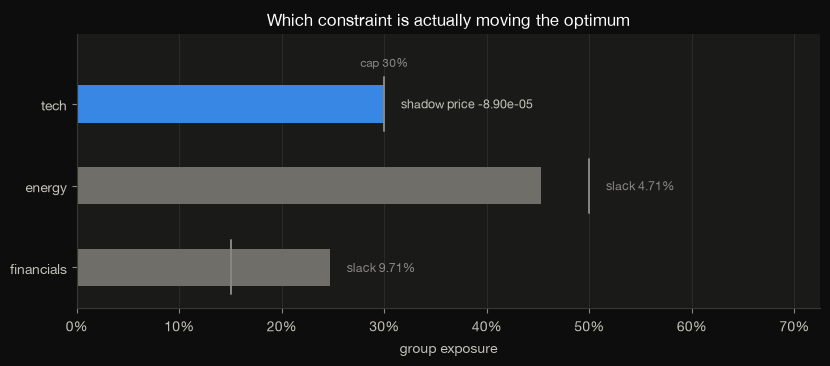

In [11]:
plot_constraint_activity(report)
plt.show()

`status` is four-way, not two:

| Status | Meaning |
| --- | --- |
| `binding` | Active *and* carrying a non-zero multiplier — relaxing it moves the optimum. |
| `weakly_active` | On its bound with a **zero** multiplier. Never named as a cause. |
| `inactive` | Slack. The multiplier is exactly zero, not merely small. |
| `unidentified` | Active, but the multiplier is not pinned by the data — `shadow_price` is `None`. |

A row's multiplier is identified only when at least one member is *strictly interior* to
its own box; that member's stationarity equation is what separates the row multiplier
from the box multiplier. When every member sits on a bound, any split between the two is
an equally valid KKT certificate, so the report declines to quote a number.

In [12]:
report.to_frame()

,weight,status,reduced_cost,intrinsic_cost,imposed_total,binding,binding_kind,shadow_price,confidence
asset,,,,,,,,,
ASSET_00,0.12785,interior,-0,NaN,0,own,interior,NaN,unique
ASSET_01,0.235,interior,-0,NaN,0,own,interior,NaN,unique
ASSET_02,0.12656,interior,-0,NaN,0,own,interior,NaN,unique
ASSET_03,0.078084,interior,-0,NaN,0,own,interior,NaN,unique
ASSET_04,0.15362,interior,-0,NaN,0,own,interior,NaN,unique
ASSET_05,0.091321,interior,-0,NaN,0,own,interior,NaN,unique
ASSET_06,0.14638,interior,-0,NaN,0,own,interior,NaN,unique
ASSET_07,0.041183,interior,-0,NaN,0,own,interior,NaN,unique
ASSET_08,0,at_lower,2.4122e-06,-8.6588e-05,8.9001e-05,tech,group_cap,-8.9001e-05,unique


And the per-asset frame as a picture: eight assets are where the objective wants them, one
is not. The 0% holding has no bar to see — exactly the case a plain weights chart cannot
explain — so it gets a baseline tick and the name of the row responsible for it.

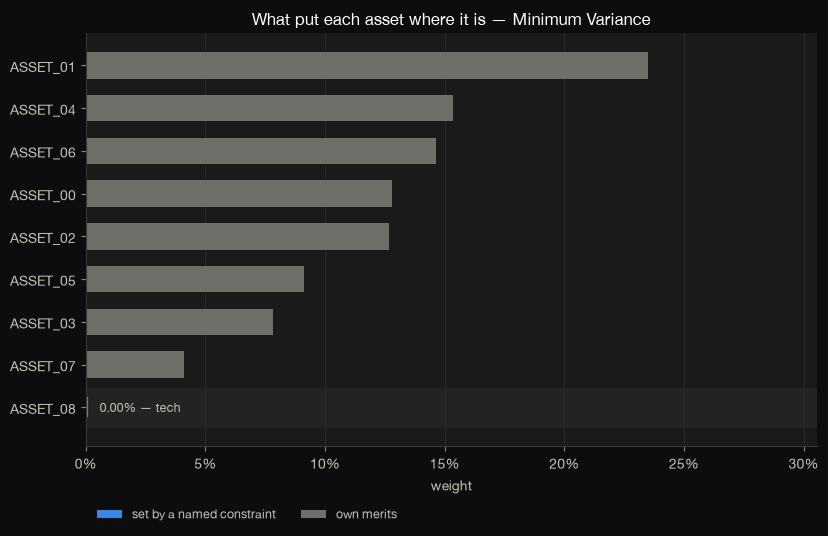

In [13]:
plot_asset_attribution(report)
plt.show()

In [14]:
print("binding rows :", [c.name for c in report.binding()])
print("quality      :", report.quality, f"(stationarity {report.stationarity:.2e})")
print()

for a in report.assets_detail:
    if a.status != "interior":
        print(f"{a.asset:<12} {a.status:<12} primary={str(a.primary):<12} {a.confidence}")

binding rows : ['tech']
quality      : exact (stationarity 2.72e-04)

ASSET_08     at_lower     primary=tech         unique


In [15]:
at_bound = next((a.asset for a in report.assets_detail if a.status != "interior"), assets[0])
report.for_asset(at_bound)

AssetAttribution(asset='ASSET_08', weight=0.0, status='at_lower', reduced_cost=2.412174580967985e-06, intrinsic_cost=-8.658846672915388e-05, imposed=(('tech', 8.900064131012186e-05),), primary='tech', primary_kind='group_cap', primary_shadow_price=-8.900064131012186e-05, confidence='unique', reason=None)

The decomposition behind that one label. `own merit` is negative — the asset wants in on
the objective's own terms — and the charge from `tech` is what pushes the net over zero.
Ranking these **terms** is what makes "binding: tech" possible: ranking the raw
multipliers would name the box bound every time, because at a zero weight the box
multiplier *is* the entire reduced cost.

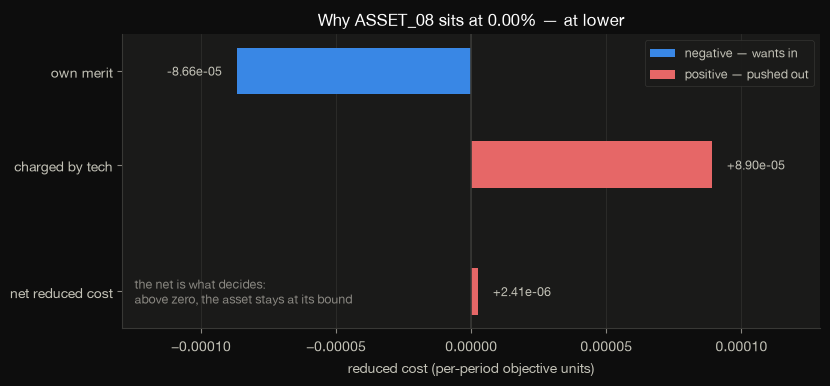

In [16]:
plot_reduced_cost(report, at_bound)
plt.show()

A JSON-serializable digest also lands in `result.metadata`, so consumers that never call
`explain` — a backtest log, a report pipeline — still see the convergence grade and which
rows moved the optimum.

In [17]:
detailed.metadata

{'iterations': 16,
 'kkt_residual': 6.427934096109311e-08,
 'stationarity': 0.00027224746864634307,
 'dual_quality': 'exact',
 'n_binding_constraints': 1,
 'binding_constraints': ['tech']}

### Printing the whole report

`explain_text()` reads the report as prose, which is right when you are looking at one
asset. Two other renderings exist for when a **person has to read the whole thing** or a
**machine has to store it**:

* `to_table()` — the same facts as fixed-width tables: a header block, one row per named
  constraint, one row per asset, then the notes that qualify them. Deliberately pure
  ASCII, so it survives a log file, a CI artifact and a non-UTF-8 console unchanged.
  `max_assets=` trims the asset table, and says so rather than dropping rows silently.
* `to_dict()` / `to_json()` — the report serialized whole, nothing rounded and nothing
  dropped, with plain Python scalars throughout.

Both are views over the same fields; neither recomputes anything.

In [18]:
print(report.to_table())

CONSTRAINT ATTRIBUTION -- Minimum Variance
assets           9
objective        variance (minimize)
dual quality     exact
stationarity     2.72e-04
KKT residual     6.43e-08
cost of capital  +9.622e-05 per unit
binding rows     1 of 3: tech

CONSTRAINTS
name        kind       activity      bound  slack  multiplier  shadow price  status
----------  ---------  --------  ---------  -----  ----------  ------------  --------
tech        group_cap    30.00%  <= 30.00%  0.00%  +8.900e-05    -8.900e-05  binding
energy      group_row    45.29%  <= 50.00%  4.71%  +0.000e+00    +0.000e+00  inactive
financials  group_row    24.71%  >= 15.00%  9.71%  +0.000e+00    +0.000e+00  inactive

ASSETS
asset     weight  status     own merit     imposed         net  cause             confidence
--------  ------  --------  ----------  ----------  ----------  ----------------  ----------
ASSET_08   0.00%  at lower  -8.659e-05  +8.900e-05  +2.412e-06  tech (group_cap)  unique
ASSET_01  23.50%  interior         n

The JSON keeps the distinction the report exists to draw: a number that cannot be stood
behind stays `null`, and never becomes a `0.0` that would read as "this constraint costs
nothing". `report.to_json()` is the whole document as one string — below are its
top-level keys and the first row of each table.

In [19]:
payload = report.to_dict()
print("top-level keys:", list(payload))
print()
print(json.dumps(payload["constraints"][0], indent=2))
print()
print(json.dumps(payload["assets"][0], indent=2))

top-level keys: ['schema', 'method', 'objective', 'sense', 'available', 'quality', 'reason', 'diagnostics', 'budget', 'constraints', 'assets', 'warnings']

{
  "name": "tech",
  "kind": "group_cap",
  "activity": 0.30000002682209015,
  "lower": 0.0,
  "upper": 0.3,
  "slack": -2.682209016002801e-08,
  "multiplier": 8.900064131012186e-05,
  "shadow_price": -8.900064131012186e-05,
  "status": "binding",
  "members": [
    "ASSET_04",
    "ASSET_06",
    "ASSET_08"
  ]
}

{
  "asset": "ASSET_00",
  "weight": 0.12785106897354126,
  "status": "interior",
  "reduced_cost": -0.0,
  "intrinsic_cost": null,
  "imposed": [],
  "cause": "own",
  "cause_kind": "interior",
  "cause_shadow_price": null,
  "confidence": "unique",
  "reason": null
}


## 5. A shadow price really is a derivative

`shadow_price` is `∂(named objective) / ∂(active limit)`. For a *minimized* objective
against a *cap* it is negative: raising the cap lowers variance. The claim is checkable —
re-solve at perturbed caps and take a central finite difference.

In [20]:
h = 0.01
up = jf.minimum_variance(returns, constraints=[jf.GroupCap("tech", tech, max=TECH_CAP + h)])
dn = jf.minimum_variance(returns, constraints=[jf.GroupCap("tech", tech, max=TECH_CAP - h)])

fd = (variance(up) - variance(dn)) / (2 * h)
reported = jf.explain(capped).constraints_frame().loc["tech", "shadow_price"]

print(f"central finite difference d(variance)/d(cap) : {fd:.8f}")
print(f"reported shadow price                       : {reported:.8f}")
print(f"relative disagreement                       : {abs(fd - reported) / abs(fd):.2e}")

central finite difference d(variance)/d(cap) : -0.00008897
reported shadow price                       : -0.00008902
relative disagreement                       : 5.42e-04


Sweeping the cap traces the whole trade-off curve. Because only the constraint *values*
travel as traced arguments — the projection kind and the shapes `(n_assets, n_rows)` are
the only static parts — perturbing a limit reuses the already-compiled kernel. An
interactive relaxation is cheap.

In [21]:
rows = []
for cap in np.round(np.arange(0.15, 0.90, 0.05), 2):
    res = jf.minimum_variance(returns, constraints=[jf.GroupCap("tech", tech, max=float(cap))])
    row = jf.explain(res).constraints_frame().loc["tech"]
    rows.append(
        {
            "cap": float(cap),
            "tech_exposure": exposure(res, tech),
            "variance": variance(res),
            "shadow_price": row["shadow_price"],
            "status": row["status"],
        }
    )

sweep = pd.DataFrame(rows).set_index("cap")
sweep

,tech_exposure,variance,shadow_price,status
cap,,,,
0.15,0.15,5.1391e-05,-0.0001369,binding
0.2,0.2,4.5114e-05,-0.00011806,binding
0.25,0.25,3.9575e-05,-0.00010352,binding
0.3,0.3,3.4763e-05,-8.9016e-05,binding
0.35,0.35,3.0626e-05,-7.7355e-05,binding
0.4,0.4,2.7021e-05,-6.6847e-05,binding
0.45,0.45,2.3938e-05,-5.6428e-05,binding
0.5,0.5,2.1377e-05,-4.5985e-05,binding
0.55,0.55,1.934e-05,-3.5502e-05,binding


Note where the sweep turns. Unconstrained tech exposure is ~71.6%, so once the cap clears
that the row goes `inactive`, its multiplier is **exactly** zero rather than merely small,
and the variance curve flattens onto the unconstrained optimum. The tangent in the plot
below is drawn from the reported shadow price alone — it is not fitted to the curve.

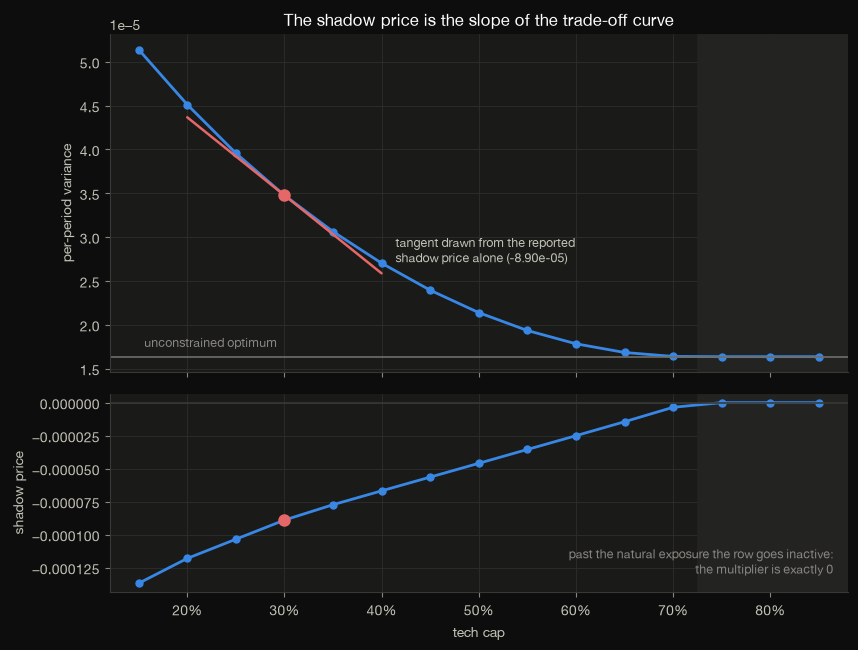

In [22]:
plot_cap_sweep(
    sweep,
    base_cap=TECH_CAP,
    base_variance=variance(capped),
    base_shadow=reported,
    free_variance=variance(free),
)
plt.show()

### Signs, and units

| Objective | Active bound | `multiplier` θ | `shadow_price` | Reading |
| --- | --- | --- | --- | --- |
| minimize (variance, CVaR) | cap | > 0 | −θ < 0 | raising the cap **lowers** variance |
| minimize | floor | < 0 | −θ > 0 | raising the floor **raises** variance |
| maximize (Sharpe, utility) | cap | > 0 | +θ > 0 | raising the cap **raises** Sharpe |
| maximize | floor | < 0 | +θ < 0 | raising the floor **lowers** Sharpe |

Relaxing a constraint can only ever weakly improve the optimum; only the presentation
flips. Multipliers are reported in the objective's own **per-period** units and are
deliberately *not* annualized — ×252 is right for variance (linear in the covariance) and
wrong for Sharpe (√252), so scaling would be wrong in a different way for each method.

In [23]:
tech_cap = [jf.GroupCap("tech", tech, max=TECH_CAP)]
fins_floor = [
    jf.GroupCap("tech", tech, max=TECH_CAP),
    jf.GroupFloor("financials", financials, min=0.30),
]

regimes = (
    ("minimize + cap", capped, "tech"),
    ("maximize + cap", jf.maximum_sharpe(returns, constraints=tech_cap), "tech"),
    ("minimize + floor", jf.minimum_variance(returns, constraints=fins_floor), "financials"),
)

signs = {
    label: jf.explain(result).constraints_frame().loc[row, ["multiplier", "shadow_price", "status"]]
    for label, result, row in regimes
}
pd.DataFrame(signs).T

,multiplier,shadow_price,status
minimize + cap,8.9016e-05,-8.9016e-05,binding
maximize + cap,0.11839,0.11839,binding
minimize + floor,-3.0051e-05,3.0051e-05,binding


## 6. The report refuses rather than guesses

Every entry below is *enforced*, not merely documented. When a number cannot be stood
behind, it comes back `None`.

**Scale-invariant objectives have no cost of capital.** Sharpe and the diversification
ratio are degree-0 homogeneous, so by Euler's identity `g'w* = 0` and "relax the budget"
is meaningless. Detected numerically — a custom scale-invariant objective gets the same
protection.

In [24]:
sharpe_report = jf.explain(
    jf.maximum_sharpe(returns, constraints=[jf.GroupCap("tech", tech, max=TECH_CAP)])
)
print("budget_shadow_price :", sharpe_report.budget_shadow_price)
print("budget_note         :", sharpe_report.budget_note)
for w in sharpe_report.warnings:
    print("warning             :", w)

budget_shadow_price : None
budget_note         : not meaningful: the objective is scale-invariant (degree-0 homogeneous), so the optimum is unchanged by a change of budget


**Non-smooth objectives — `min_cvar` refuses outright.** Its objective contains
`max(loss - tau, 0)` and at the optimum `tau` sits exactly on a sample loss, generically.
`jax.grad` returns one arbitrary subgradient there, so stationarity need not hold even at
the exact solution. Quality is `unreliable`, every shadow price is `None`, and the primal
active set is still reported alongside `aux_stationarity` — how far the VaR threshold is
from its own optimum.

In [25]:
cvar_report = jf.explain(
    jf.min_cvar(returns, constraints=[jf.GroupCap("tech", tech, max=TECH_CAP)])
)
print("quality          :", cvar_report.quality)
print("reason           :", cvar_report.reason)
print("aux_stationarity :", cvar_report.aux_stationarity)
cvar_report.constraints_frame()[["activity", "slack", "multiplier", "shadow_price", "status"]]

quality          : unreliable
reason           : the CVaR objective is non-smooth at its optimum, so the gradient is one arbitrary subgradient and stationarity need not hold even at the exact solution; shadow prices are suppressed
aux_stationarity : 0.12224459648132324


,activity,slack,multiplier,shadow_price,status
name,,,,,
tech,0.3,-2.6822e-08,NaN,NaN,binding


**Unconverged solves are suppressed**, judged against the tolerance you asked for — and
detected by a KKT residual computed *independently* of the solver's own convergence
measure, which for the optax family cannot reveal it.

In [26]:
rushed = jf.minimum_variance(
    returns,
    config=jf.OptimizerConfig(
        solver="sgd",
        max_iter=5,
        constraints=[jf.GroupCap("tech", tech, max=TECH_CAP)],
    ),
)
rushed_report = jf.explain(rushed)
print("quality :", rushed_report.quality)
print("reason  :", rushed_report.reason)
print("shadow prices:", [c.shadow_price for c in rushed_report.constraints])

quality : unreliable
reason  : the solve did not converge tightly enough (KKT residual 1.44e-04 against a requested tol of 1.0e-07; relative 3.91e-01); shadow prices are suppressed
shadow prices: [None]


**Optimizers with no duals at all.** `equal_weight`, `inverse_volatility`, `risk_parity`,
the graph methods and the learning policies solve no constrained program. These are
*feasible by construction*, not *optimal subject to*, so a zero weight is caused by the
construction and not by a constraint. `explain()` still returns a well-formed report,
with `available=False` and a **specific** reason.

In [27]:
print(jf.explain(jf.equal_weight(returns)).explain_text())
print()
print(jf.explain(jf.risk_parity(returns)).explain_text())

Constraint attribution — Equal Weight (9 assets)
  unavailable: equal_weight assigns 1/N analytically; no optimization program is solved, so no constraint is ever active

Constraint attribution — Risk Parity (ERC) (9 assets)
  unavailable: risk_parity solves a log-barrier program (min 0.5 x'Sigma x - (1/N) sum log x); the barrier keeps every x strictly positive so no bound is ever active, and the budget is imposed by normalizing the fixed point rather than as a constraint. For per-asset attribution on this method see metadata["risk_contributions"]


And they **raise rather than ignore** a named constraint they cannot honor. Accepting a
cap and quietly returning weights that violate it is the one outcome worse than refusing.

`multi_period_mean_variance` refuses for a different reason: the row-wise projection *can*
take per-period group caps — the feasible set stays a Cartesian product over periods — but
a cap on a *horizon aggregate* is not expressible, and which of the two a user means is
undecided. `equal_weight`, `inverse_volatility` and the graph methods (HRP, HERC, MST)
refuse one step earlier still: they accept no `constraints` argument at all.

In [28]:
cap = [jf.GroupCap("tech", tech, max=TECH_CAP)]

try:
    jf.risk_parity(returns, constraints=cap)
except NotImplementedError as exc:
    print(f"risk_parity:\n  {exc}\n")

try:
    jf.multi_period_mean_variance(returns, config=jf.OptimizerConfig(constraints=cap))
except NotImplementedError as exc:
    print(f"multi_period_mean_variance:\n  {exc}\n")

try:
    jf.hierarchical_risk_parity(returns, constraints=cap)
except TypeError as exc:
    print(f"hierarchical_risk_parity:\n  {exc}")

risk_parity:
  risk_parity is a closed-form weighting and cannot honor named constraints ('tech'). It has no optimization program for a cap to constrain. Use minimum_variance or mean_variance instead, which solves a constrained problem.

multi_period_mean_variance:
  multi_period_mean_variance does not yet support named constraints ('tech'). Per-period group caps are expressible — the projection is applied row-wise, so the feasible set stays a product over periods — but caps on a horizon aggregate are not, and which one a cap should mean is undecided. Use scalar `weight_bounds` for now, or apply the cap with a single-period optimizer.

hierarchical_risk_parity:
  hierarchical_risk_parity() got an unexpected keyword argument 'constraints'


## 7. Infeasible sets are rejected up front

Because the rows are disjoint, the reachable total is exactly the sum of each row's
reachable interval plus the ungrouped assets' box — so the feasibility test is
**necessary and sufficient**. Never a false alarm, and a set that compiles can always be
satisfied. `check_feasible` validates a set without solving anything.

In [29]:
attempts = {
    "caps that cannot fund the budget": [
        jf.GroupCap("tech", tech, max=0.30),
        jf.GroupCap("energy", energy, max=0.25),
        jf.GroupCap("financials", financials, max=0.30),
    ],
    "overlapping groups": [
        jf.GroupCap("tech", tech, max=0.30),
        jf.GroupCap("us_large", [tech[0], energy[0]], max=0.40),
    ],
    "a typo in a ticker": [jf.GroupCap("tech", [tech[0], "NOPE_01"], max=0.30)],
}

for label, cons in attempts.items():
    try:
        check_feasible(cons, assets)
    except (InfeasibleConstraints, ValueError, KeyError) as exc:
        message = " ".join(str(exc).strip("\"'").split())
        print(f"{label}\n  {type(exc).__name__}: {message}\n")
    else:
        print(f"{label}\n  (feasible)\n")

caps that cannot fund the budget
  InfeasibleConstraints: the constraints admit a total weight only in [0, 0.85], but the budget requires 1 — above the reachable range by 0.15. Rows: 'tech' in [0, 0.3], 'energy' in [0, 0.25], 'financials' in [0, 0.3] and every asset belongs to a group.

overlapping groups
  ValueError: GroupCap('us_large') and 'tech' both constrain 'ASSET_04'. Group constraints must partition the universe — each asset may belong to at most one group. That disjointness is what makes the projection exact and the shadow prices trustworthy; overlapping groups would need an alternating projection that is inexact at any finite iteration count. Workaround: express one dimension as a partition and price the other with l2_reg or a custom objective penalty.

a typo in a ticker
  KeyError: GroupCap('tech'): unknown asset 'NOPE_01' — it is not in the returns panel.



Validation is two-stage, and the first stage does not need the universe at all: anything
structural — a floor above its own cap, a constraint that constrains nothing, a duplicate
name — is caught when the spec is *constructed*, long before any moments are estimated.

In [30]:
try:
    jf.GroupCap("tech", tech, min=0.40, max=0.30)
except ValueError as exc:
    print("at construction:", exc)

try:
    jf.GroupCap("tech", tech)
except ValueError as exc:
    print("at construction:", exc)

try:
    jf.OptimizerConfig(
        constraints=[jf.GroupCap("tech", tech, max=0.3), jf.GroupCap("tech", energy, max=0.4)]
    )
except ValueError as exc:
    print("at config      :", exc)

at construction: constraint 'tech' has min=0.4 above max=0.3
at construction: constraint 'tech' sets neither min nor max — it would constrain nothing. Pass max=... for a cap, min=... for a floor, or both for a band.
at config      : OptimizerConfig.constraints has two entries named 'tech'; names must be unique so attribution can refer to them unambiguously


## 8. Switching the diagnostics off

Attribution costs one gradient and two projections per solve, both *outside* the solver
loop — negligible next to the solve itself. It never touches the weights. For tight
backtest loops where the explanation is never read, `OptimizerConfig(attribution=False)`
opts out, and `explain()` then reports `available=False` rather than failing.

In [31]:
lean = jf.minimum_variance(
    returns,
    config=jf.OptimizerConfig(
        attribution=False,
        constraints=[jf.GroupCap("tech", tech, max=TECH_CAP)],
    ),
)

print("max |weight change| vs. the captured solve:", np.abs(lean.weights - capped.weights).max())
print("attribution payload:", lean.attribution)
print()
print(jf.explain(lean).explain_text())

max |weight change| vs. the captured solve: 0.0
attribution payload: None

Constraint attribution — Minimum Variance (9 assets)
  unavailable: Minimum Variance does not emit solver diagnostics — it is feasible by construction rather than optimal subject to constraints, so a zero weight is caused by the construction, not by a constraint


## What is not expressible

The honest list, from the [constraints guide](../docs/guide/constraints.md):

- **Overlapping or nested groups** — structural. Disjoint supports are exactly what
  decouples the row multipliers and keeps the projection exact; the projected-gradient
  stopping test only certifies KKT stationarity for an *exact* projection. *Workaround:*
  express one dimension as a partition and price the other softly with `l2_reg` or a
  penalty inside a custom objective.
- **Rows with coefficients other than 1** — beta or factor-exposure limits (`a'w <= c`).
  The inner bisection generalizes; the outer budget bisection is only provably monotone
  for all-ones rows.
- **Gross-exposure / leverage caps** (`||w||₁ <= G`) — needs a third bisection level.
- **Cardinality and minimum position size** — non-convex, so there is no Euclidean
  projection for a projected-gradient method to converge through. Needs a MIQP.
- **Constraints on the CVaR auxiliary variable** — `tau` is unconstrained by construction.
- **Hard turnover caps** — still soft; costs are priced, not capped. See the
  [multi-period guide](../docs/guide/multiperiod.md).

And finally: a shadow price is `∂f*/∂c` on *in-sample estimated moments*. It says what
the optimizer would have done with a different limit — not what the market will do.